In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fake = Faker()

stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D']
items = ['Product_1', 'Product_2', 'Product_3', 'Product_4', 'Product_5']
regions = ['North', 'South', 'East', 'West']

data = []

for i in range(100000):
    date = fake.date_between(start_date='-2y', end_date='today')
    store = random.choice(stores)
    item = random.choice(items)
    region = random.choice(regions)
    sales = random.randint(10, 500)

    data.append([date, store, item, region, sales])

columns = ['Date', 'Store', 'Item', 'Region', 'Sales']

df = pd.DataFrame(data, columns=columns)

df.head()

,Date,Store,Item,Region,Sales
0,2025-09-27,Store_A,Product_1,West,256
1,2025-07-01,Store_D,Product_5,East,19
2,2025-02-18,Store_A,Product_1,East,424
3,2024-10-04,Store_B,Product_4,East,106
4,2026-01-28,Store_B,Product_4,West,31


In [4]:

df['Date'] = pd.to_datetime(df['Date'])


print(df.isnull().sum())


df = df.drop_duplicates()

df.info()

Date      0
Store     0
Item      0
Region    0
Sales     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 99832 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    99832 non-null  datetime64[ns]
 1   Store   99832 non-null  object        
 2   Item    99832 non-null  object        
 3   Region  99832 non-null  object        
 4   Sales   99832 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.6+ MB


In [5]:
print(df.describe())

                                Date         Sales
count                          99832  99832.000000
mean   2025-04-06 00:29:18.602451712    254.991466
min              2024-04-06 00:00:00     10.000000
25%              2024-10-05 00:00:00    132.000000
50%              2025-04-06 00:00:00    256.000000
75%              2025-10-06 00:00:00    378.000000
max              2026-04-06 00:00:00    500.000000
std                              NaN    141.839275


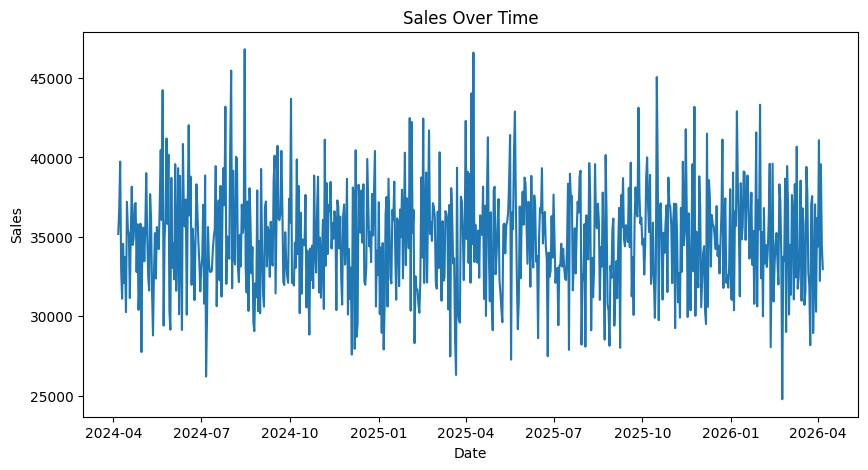

In [6]:
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

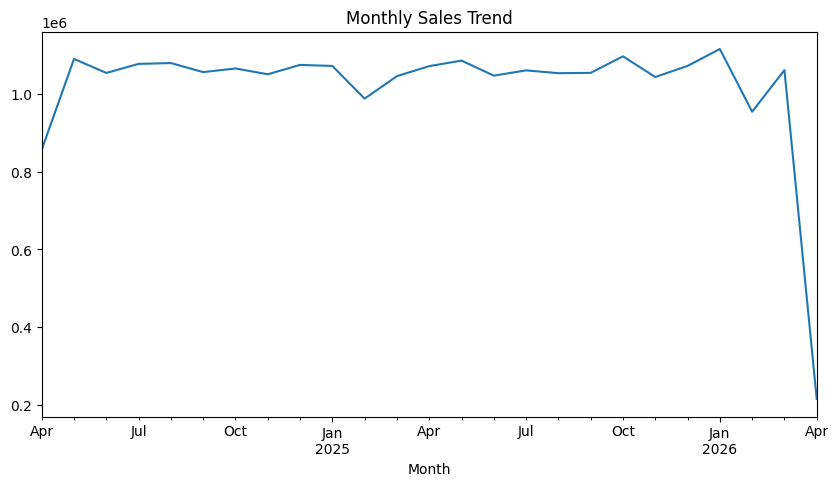

In [7]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

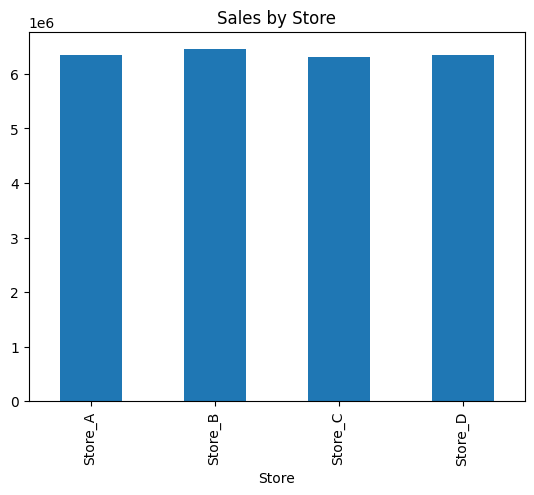

In [8]:
store_sales = df.groupby('Store')['Sales'].sum()

store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.show()

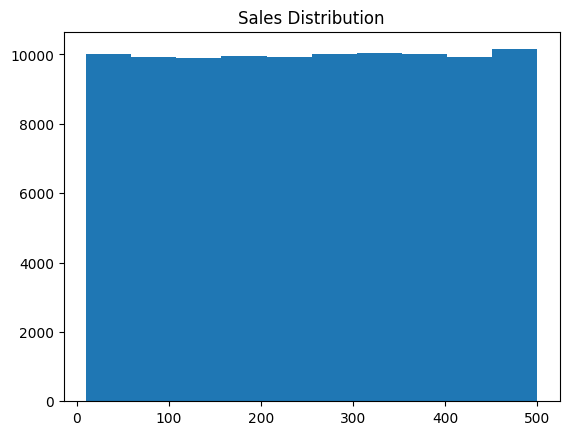

In [9]:
plt.hist(df['Sales'])
plt.title("Sales Distribution")
plt.show()

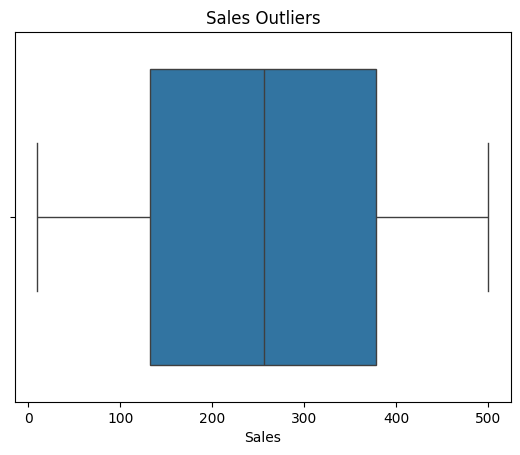

In [10]:
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

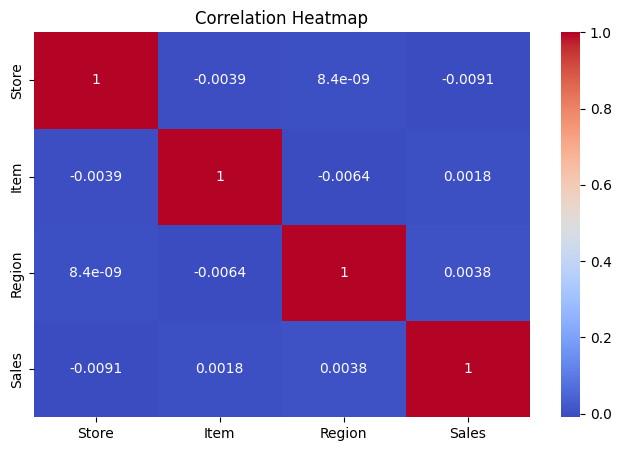

In [11]:

df_encoded = df.copy()
df_encoded['Store'] = df_encoded['Store'].astype('category').cat.codes
df_encoded['Item'] = df_encoded['Item'].astype('category').cat.codes
df_encoded['Region'] = df_encoded['Region'].astype('category').cat.codes

plt.figure(figsize=(8,5))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()